Loading the Data

In [1]:
import pandas as pd
df = pd.read_excel('Real estate valuation data set.xlsx')

Exploratory Data Analysis (EDA)

In [2]:
df.duplicated().sum()

np.int64(0)

In [3]:
df.isnull().sum()

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [4]:
df1 = df.drop(columns=['No'])

In [5]:
df1.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [6]:
df1.describe()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,2013.148953,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,0.281995,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,2012.666667,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,2012.916667,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,2013.166667,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,2013.416667,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,2013.583333,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [7]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X1 transaction date                     414 non-null    float64
 1   X2 house age                            414 non-null    float64
 2   X3 distance to the nearest MRT station  414 non-null    float64
 3   X4 number of convenience stores         414 non-null    int64  
 4   X5 latitude                             414 non-null    float64
 5   X6 longitude                            414 non-null    float64
 6   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 22.8 KB


In [8]:
df1.columns

Index(['X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

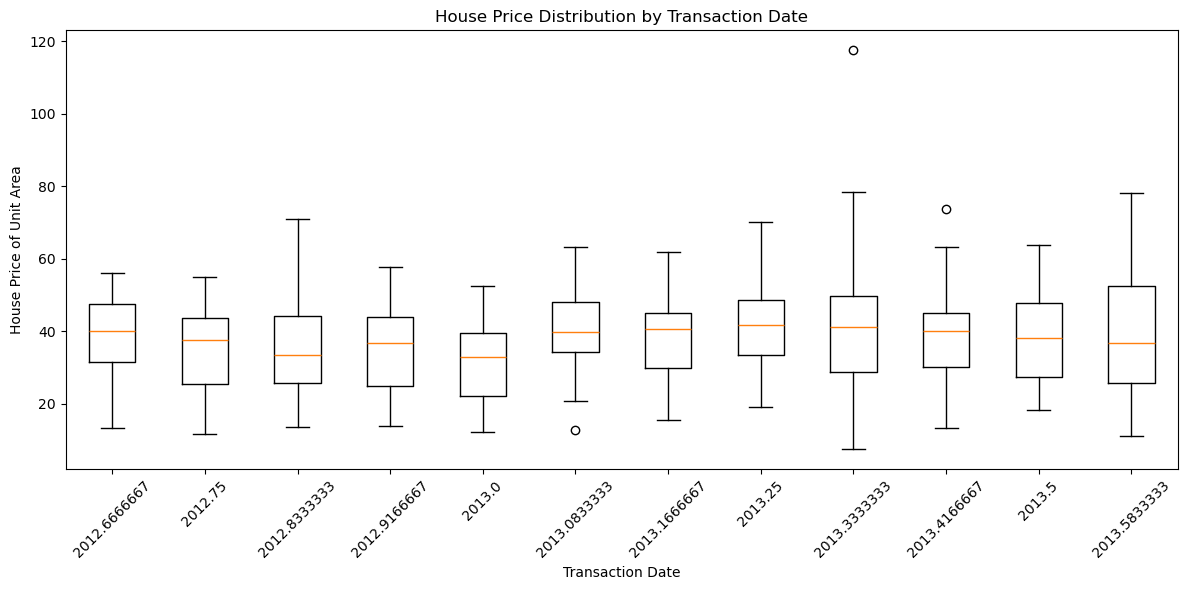

In [9]:
import matplotlib.pyplot as plt

dates = sorted(df1["X1 transaction date"].unique())
data = [df1[df1["X1 transaction date"] == d]["Y house price of unit area"] for d in dates]

plt.figure(figsize=(12,6))
plt.boxplot(data, tick_labels=[str(d) for d in dates])

plt.xticks(rotation=45)
plt.xlabel("Transaction Date")
plt.ylabel("House Price of Unit Area")
plt.title("House Price Distribution by Transaction Date")
plt.tight_layout()
plt.show()

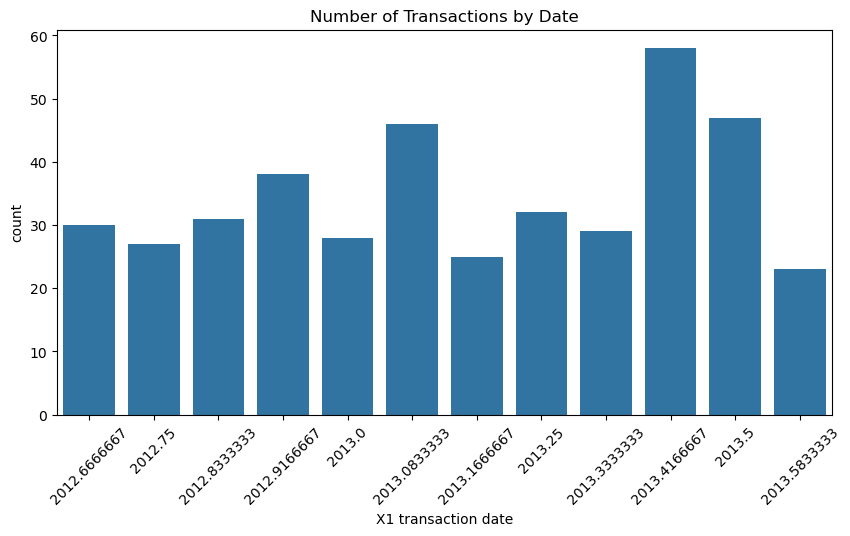

In [10]:
import seaborn as sns
plt.figure(figsize=(10,5))

sns.countplot(
    x=df1["X1 transaction date"]
)

plt.xticks(rotation=45)
plt.title("Number of Transactions by Date")

plt.show()

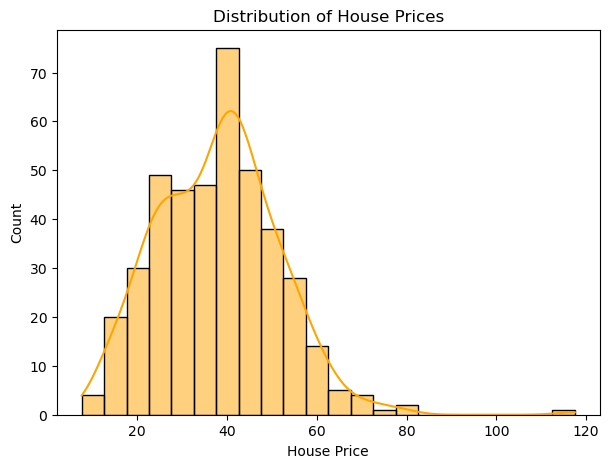

In [11]:
plt.figure(figsize=(7,5))

sns.histplot(
    df1["Y house price of unit area"],
    kde=True,
    color="orange"
)

plt.xlabel("House Price")
plt.title("Distribution of House Prices")

plt.show()

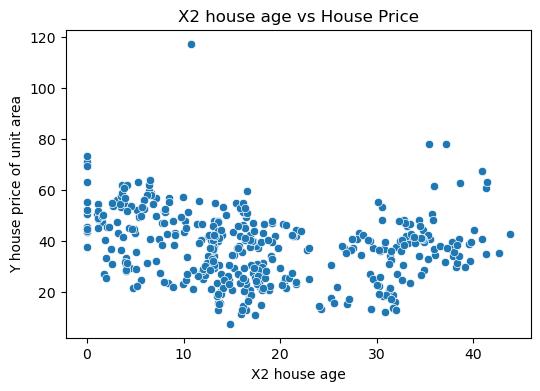

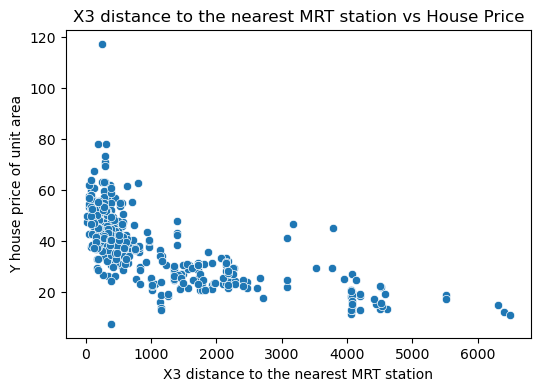

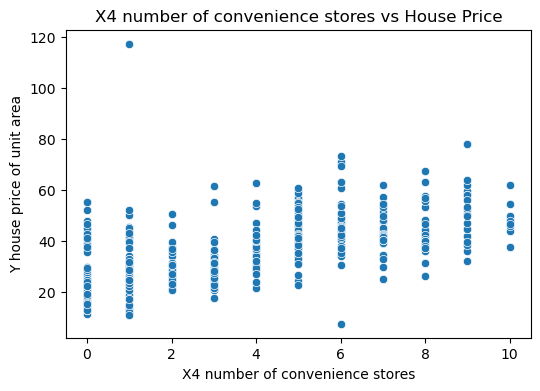

In [12]:
features = [
    'X2 house age',
    'X3 distance to the nearest MRT station',
    'X4 number of convenience stores'
]

for col in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df1, x=col, y='Y house price of unit area')
    plt.title(f'{col} vs House Price')
    plt.show()

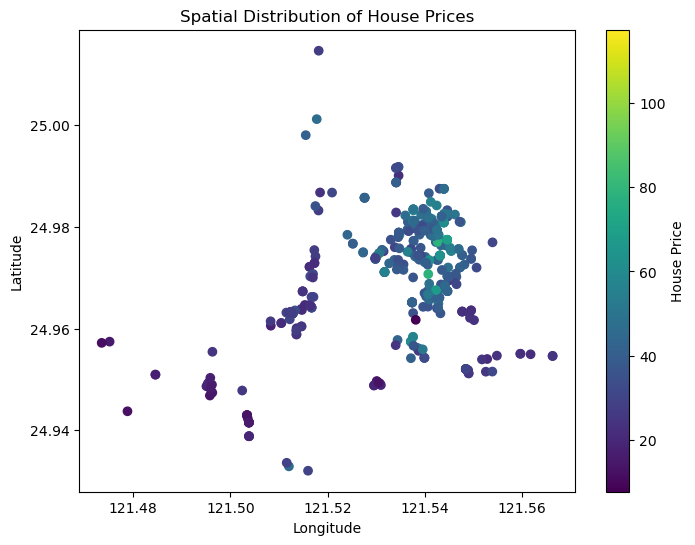

In [13]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    df1['X6 longitude'],
    df1['X5 latitude'],
    c=df1['Y house price of unit area'],
    cmap='viridis'
)

plt.colorbar(scatter, label='House Price')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Spatial Distribution of House Prices')
plt.show()

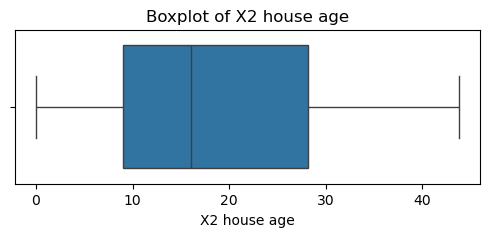

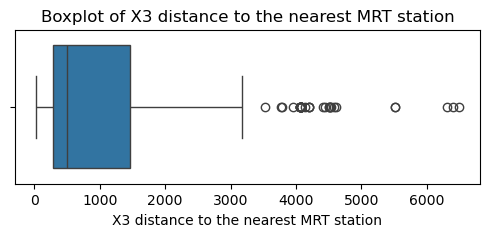

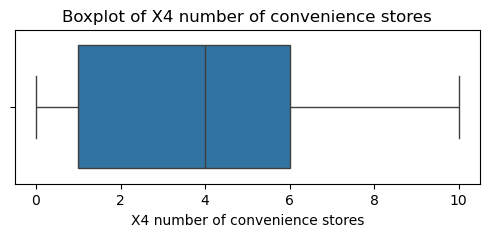

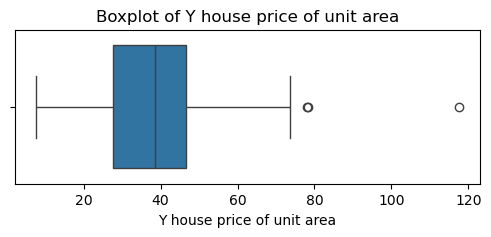

In [14]:
cols = [
    'X2 house age',
    'X3 distance to the nearest MRT station',
    'X4 number of convenience stores',
    'Y house price of unit area'
]

for col in cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Feature Selection and Analysis

In [15]:
df1a = df1.copy()

In [16]:
df2 = df1a.drop('X1 transaction date', axis=1)

In [17]:
df2.head()

,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,32.0,84.87882,10,24.98298,121.54024,37.9
1,19.5,306.59470,9,24.98034,121.53951,42.2
2,13.3,561.98450,5,24.98746,121.54391,47.3
3,13.3,561.98450,5,24.98746,121.54391,54.8
4,5.0,390.56840,5,24.97937,121.54245,43.1


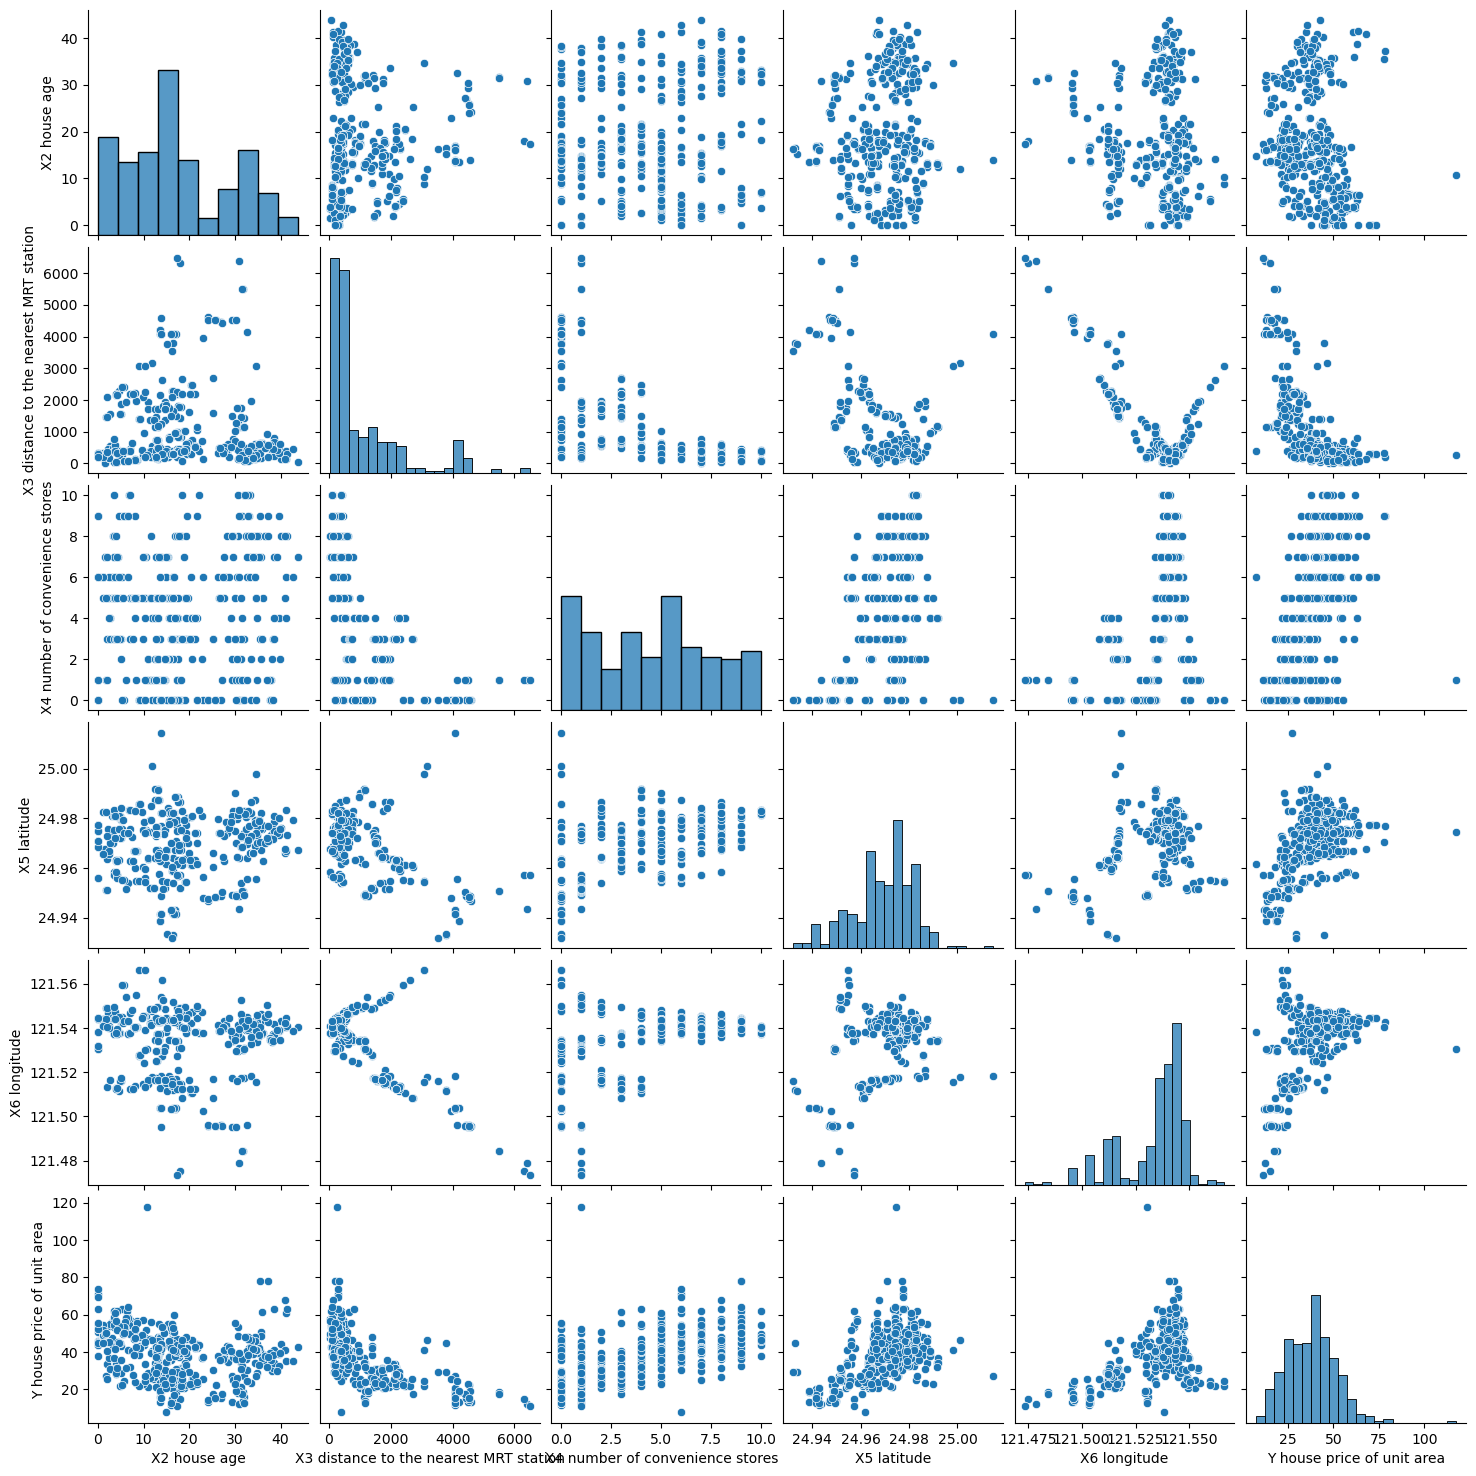

In [18]:
sns.pairplot(df2)

plt.show()

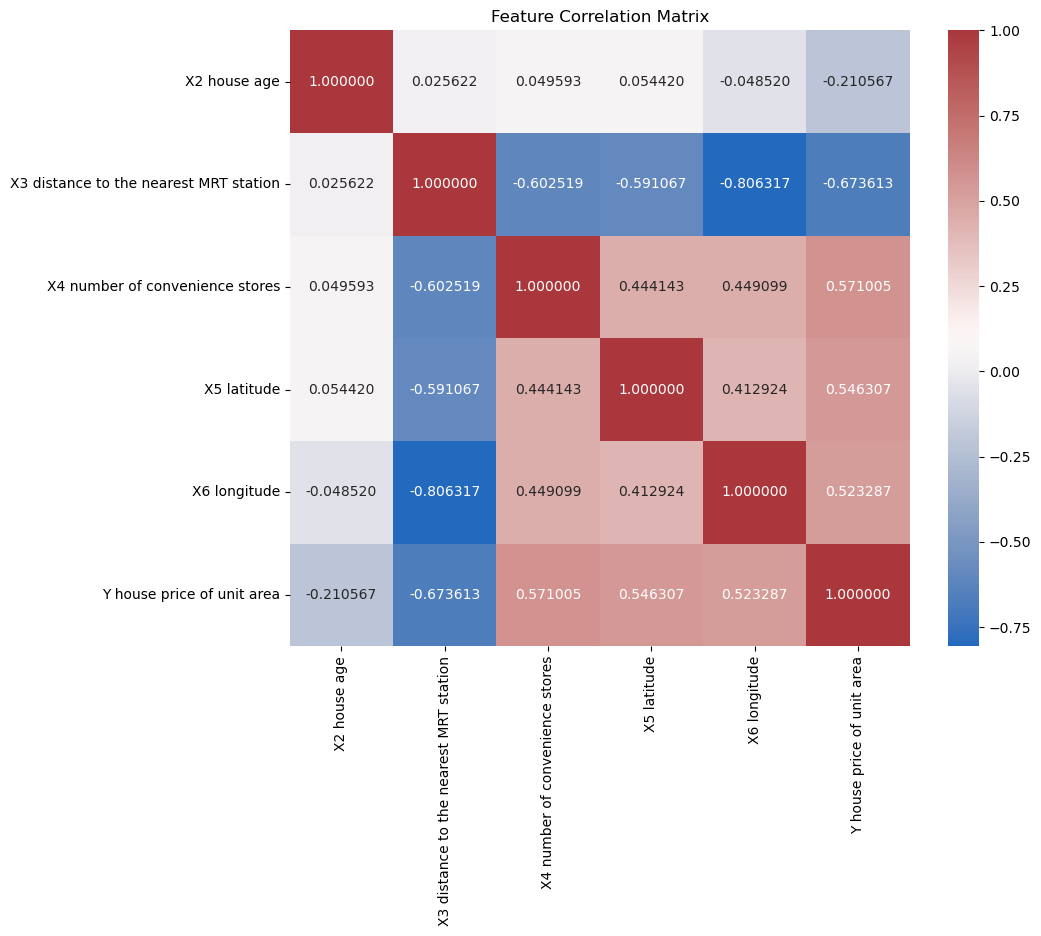

In [19]:
corr_matrix = df2.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="vlag", fmt=".6f")
plt.title("Feature Correlation Matrix")
plt.show()

Model Selection and Evaluation

In [20]:
y = df2['Y house price of unit area']
X = df2.drop('Y house price of unit area', axis=1)

In [21]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ("scaler",    StandardScaler()),
    ("regressor", LinearRegression()),
])

pipeline.fit(X_train, y_train)
 
y_pred = pipeline.predict(X_test)
 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

RMSE : 7.39
R²   : 0.6746


In [22]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", Ridge(alpha=17.225860)),
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

RMSE : 7.36
R²   : 0.6771


In [23]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-4, 4, 100)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", RidgeCV(alphas=alphas, cv=5))
])

pipeline.fit(X_train, y_train)

best_alpha = pipeline.named_steps["regressor"].alpha_
print("Best alpha:", best_alpha)

y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Best alpha: 17.886495290574352
RMSE : 7.36
R²   : 0.6771


In [24]:
best_ridge = pipeline

y_pred = best_ridge.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.3f}")
print(f"Test R²: {r2:.3f}")

Test RMSE: 7.360
Test R²: 0.677


In [25]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

poly_model.fit(X_train, y_train)

y_pred = poly_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.3f}")
print(f"Test R²: {r2:.3f}")

Test RMSE: 6.469
Test R²: 0.751


In [26]:
from sklearn.svm import SVR

svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", SVR())
])

svr_model.fit(X_train, y_train)

y_pred = svr_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.3f}")
print(f"Test R²: {r2:.3f}")

Test RMSE: 7.344
Test R²: 0.679


In [28]:
from sklearn.model_selection import GridSearchCV
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", SVR())
])

param_grid = {
    "regressor__kernel": ["linear", "rbf", "poly"],
    "regressor__C": [0.1, 1, 10, 100],
    "regressor__epsilon": [0.01, 0.1, 0.5, 1],
    "regressor__gamma": ["scale", "auto"]
}

grid_svr = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_svr.fit(X_train, y_train)

print("Best Parameters:")
print(grid_svr.best_params_)

print("Best CV R²:")
print(grid_svr.best_score_)

Best Parameters:
{'regressor__C': 10, 'regressor__epsilon': 0.5, 'regressor__gamma': 'scale', 'regressor__kernel': 'rbf'}
Best CV R²:
0.6322193760769137


In [29]:
best_svr = grid_svr.best_estimator_

y_pred = best_svr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.3f}")
print(f"Test R²: {r2:.3f}")

Test RMSE: 6.219
Test R²: 0.769


In [30]:
from xgboost import XGBRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb = XGBRegressor(
    random_state=42,
    n_estimators=100
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

y_pred_test = xgb.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

RMSE: 6.760
R²: 0.728


In [32]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("Best CV R²:")
print(grid.best_score_)

best_xgb = grid.best_estimator_

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Best CV R²:
0.660660834183216


In [33]:
best_xgb = grid.best_estimator_

y_pred = best_xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.3f}")
print(f"Test R²: {r2:.3f}")

Test RMSE: 5.909
Test R²: 0.792


In [34]:
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf = RandomForestRegressor(
    random_state=42,
    n_estimators=300,
        
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

y_pred_test = rf.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

RMSE: 5.822
R²: 0.798


In [35]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300,500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10,20],
    'min_samples_leaf': [1, 2, 4,8]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)
print("Best CV R²:", grid.best_score_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 500}
Best CV R²: 0.6552713254829882


In [36]:
best_rf = grid.best_estimator_

y_pred = best_rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.3f}")
print(f"Test R²: {r2:.3f}")

Test RMSE: 5.673
Test R²: 0.808


X3 distance to the nearest MRT station    0.662437
X2 house age                              0.158290
X5 latitude                               0.122579
X6 longitude                              0.044697
X4 number of convenience stores           0.011997
dtype: float64


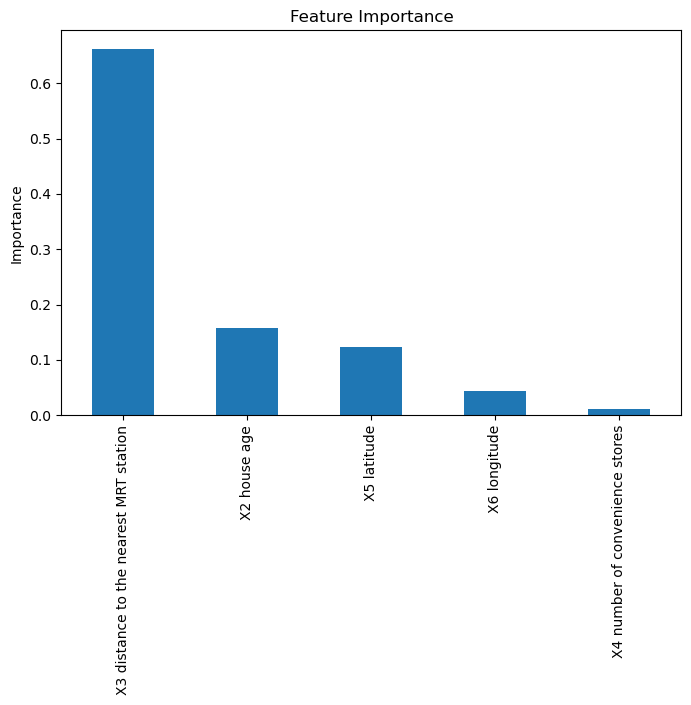

In [39]:
importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

plt.figure(figsize=(8,5))
importance.plot(kind="bar")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()